# 05 — Model Training & Comparison

**Input:**
- `data/processed/X_features.csv`  (39 × 37 feature matrix)
- `data/processed/y_target.csv`    (39 target labels: Low / Moderate / High)

**Outputs:**
- `models/<best_model>.pkl`        — best model saved to disk
- `reports/model_comparison.csv`   — CV scores across all models
- Figures: model comparison bar chart

**What this notebook does:**
1. Loads features and target
2. Splits into train / test (stratified, 80/20)
3. Scales numeric features (fit on train only — no leakage)
4. Trains 7 candidate models with Stratified 5-fold CV
5. Compares them on accuracy, precision, recall, F1
6. Selects the best model for evaluation and explainability

**Important limitation (documented):**
- n = 39 samples, p = 37 features → p/n ≈ 0.95
- This is very small for ML. Overfitting is likely.
- Results are PROTOTYPE. A larger dataset (300+) is required for
  publication-quality conclusions.
- Model choice is biased toward simple models for this reason.

In [1]:
# Step 1: Load features and target.

import pandas as pd
import numpy as np

X = pd.read_csv("../data/processed/X_features.csv")
y = pd.read_csv("../data/processed/y_target.csv").squeeze("columns")  # Series

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Target distribution:")
print(y.value_counts())
print()
print("Feature columns:")
print(X.columns.tolist())
print()
print("Any missing values?")
print("X missing:", X.isna().sum().sum())
print("y missing:", y.isna().sum())

X shape: (39, 37)
y shape: (39,)

Target distribution:
stress_level
Low         15
Moderate    13
High        11
Name: count, dtype: int64

Feature columns:
['age', 'year', 'cgpa', 'study_hours', 'attendance', 'assignment_stress', 'exam_count', 'sleep_hours', 'social_media', 'physical_activity', 'screen_time', 'financial_stress', 'social_support', 'academic_life_satisfaction', 'thought_break', 'career_stress', 'academic_performance', 'gender_Male', 'gender_Prefer not to say', 'university_Kathmandu University', 'university_Other', 'university_Pokhara University', 'university_Purbanchal University', 'university_Rajarshi Janak University', 'university_Sudurpaschim University', 'university_Tribhuvan University', 'program_BBS', 'program_BCA', 'program_BDS', 'program_BE/B.Tech', 'program_BHM', 'program_BIM', 'program_BSc CSIT', 'program_BSc Nursing', 'program_Law(LLB)', 'program_MBBS', 'part_time_job_Yes']

Any missing values?
X missing: 0
y missing: 0


## Step 2 — Train/Test Split

The dataset is split into:

- **Training set (80%)** — used to fit the model
- **Test set (20%)** — held out, used only for final evaluation

We use **stratified** splitting to preserve the class distribution
(Low/Moderate/High) in both sets. This is important with a small sample
and unbalanced-ish classes.

A fixed `random_state=42` ensures the split is reproducible.

In [2]:
# Step 2: Stratified train/test split.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20% held out for test
    stratify=y,            # preserve class ratios
    random_state=42        # reproducible
)

print("Train set size:", X_train.shape)
print("Test  set size:", X_test.shape)
print()
print("Class distribution in train:")
print(y_train.value_counts())
print()
print("Class distribution in test:")
print(y_test.value_counts())
print()
print("Proportions in train:")
print((y_train.value_counts(normalize=True) * 100).round(1))
print()
print("Proportions in test:")
print((y_test.value_counts(normalize=True) * 100).round(1))

Train set size: (31, 37)
Test  set size: (8, 37)

Class distribution in train:
stress_level
Low         12
Moderate    10
High         9
Name: count, dtype: int64

Class distribution in test:
stress_level
Low         3
Moderate    3
High        2
Name: count, dtype: int64

Proportions in train:
stress_level
Low         38.7
Moderate    32.3
High        29.0
Name: proportion, dtype: float64

Proportions in test:
stress_level
Low         37.5
Moderate    37.5
High        25.0
Name: proportion, dtype: float64


## Step 3 — Feature Scaling

Different models have different sensitivity to feature magnitude:

- **Scale-sensitive:** Logistic Regression, SVM, KNN
- **Scale-insensitive:** Decision Tree, Random Forest, XGBoost

We apply `StandardScaler` (z-score normalization: `z = (x - μ) / σ`)
so that all features have mean 0 and standard deviation 1.

**Critical rule:** The scaler is fitted on the **training set only**,
then applied to the test set. Fitting on the full dataset would leak
information from test into train and produce falsely optimistic results.

We also save the fitted scaler to disk — it must be used at prediction
time to scale new inputs the same way.

In [3]:
# Step 3: Scale features.

import os
import joblib
from sklearn.preprocessing import StandardScaler

# Create a scaler and fit it ONLY on the training data
scaler = StandardScaler()
scaler.fit(X_train)

# Transform both train and test using the training-fit scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling:")
print("  X_train mean (first 5):", X_train.iloc[:, :5].mean().round(2).tolist())
print("  X_train std  (first 5):", X_train.iloc[:, :5].std().round(2).tolist())
print()
print("After scaling:")
print("  X_train_scaled mean (first 5):", X_train_scaled[:, :5].mean(axis=0).round(6).tolist())
print("  X_train_scaled std  (first 5):", X_train_scaled[:, :5].std(axis=0).round(6).tolist())
print()
print("Shapes:")
print("  X_train_scaled:", X_train_scaled.shape)
print("  X_test_scaled :", X_test_scaled.shape)

# Save the scaler for later use (predicting on new data)
os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/scaler.pkl")
print()
print("Saved scaler to ../models/scaler.pkl")

Before scaling:
  X_train mean (first 5): [2.65, 3.45, 2.42, 2.84, 3.26]
  X_train std  (first 5): [0.91, 0.81, 1.31, 1.1, 1.15]

After scaling:
  X_train_scaled mean (first 5): [0.0, -0.0, -0.0, -0.0, -0.0]
  X_train_scaled std  (first 5): [1.0, 1.0, 1.0, 1.0, 1.0]

Shapes:
  X_train_scaled: (31, 37)
  X_test_scaled : (8, 37)

Saved scaler to ../models/scaler.pkl


## Step 4 — Baseline Model

Before training any real classifier, we establish a **baseline** using
`DummyClassifier` from scikit-learn, which always predicts the most
frequent class.

In the training set, the most frequent class is "Low" (12 of 31 samples),
so the baseline will predict "Low" for every input. Its accuracy will be
about 12/31 ≈ 38.7%.

Any real model that cannot beat this baseline is not learning anything
useful from the features.

**Note:** With only 39 samples, even beating the baseline by a small
margin is not evidence of a strong model — but it is the minimum
sanity check.

In [4]:
# Step 4: Baseline model (DummyClassifier).

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

# Create stratified 5-fold CV (this will be reused for every model)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline classifier — always predicts the most frequent class
baseline = DummyClassifier(strategy="most_frequent", random_state=42)

# Cross-validation scores on the training set
cv_acc = cross_val_score(baseline, X_train_scaled, y_train, cv=cv, scoring="accuracy")
cv_f1  = cross_val_score(baseline, X_train_scaled, y_train, cv=cv, scoring="f1_macro")

print("Baseline (most_frequent) — 5-fold CV on training set:")
print(f"  Accuracy : {cv_acc.mean():.3f}  (+/- {cv_acc.std():.3f})")
print(f"  F1 macro : {cv_f1.mean():.3f}  (+/- {cv_f1.std():.3f})")
print()
print("Per-fold accuracy:", cv_acc.round(3).tolist())
print("Per-fold F1 macro:", cv_f1.round(3).tolist())

Baseline (most_frequent) — 5-fold CV on training set:
  Accuracy : 0.386  (+/- 0.068)
  F1 macro : 0.184  (+/- 0.023)

Per-fold accuracy: [0.429, 0.5, 0.333, 0.333, 0.333]
Per-fold F1 macro: [0.2, 0.222, 0.167, 0.167, 0.167]


## Step 5 — Train & Compare Multiple Models

We train 7 candidate classifiers, all evaluated with the same
Stratified 5-fold CV on the training set:

1. Logistic Regression — linear baseline
2. Decision Tree — simple, interpretable
3. Random Forest — ensemble of trees
4. Support Vector Machine (SVM) — margin-based
5. K-Nearest Neighbors (KNN) — distance-based
6. Naive Bayes — probabilistic
7. XGBoost — gradient boosted trees

For each model we record:
- Mean CV accuracy
- Mean CV F1 macro (this is our main metric, because it weighs all 3 classes)
- Standard deviation across folds

**Note:** With only 31 training samples, CV scores are unstable.
Model ranking may shift with a larger dataset.

In [5]:
# Step 5: Encode labels for XGBoost, then run CV for all models.

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# --- Encode target labels as integers (needed for XGBoost) ---
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls:10s} -> {i}")
print()

# --- Define models (SVM without deprecated probability=True) ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (RBF)":           SVC(kernel="rbf", random_state=42),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes":         GaussianNB(),
    "XGBoost":             XGBClassifier(
                               n_estimators=200, max_depth=3, learning_rate=0.1,
                               eval_metric="mlogloss",
                               random_state=42, verbosity=0
                           ),
}

# XGBoost needs integer labels; other models use string labels
int_label_models = {"XGBoost"}

# --- Run CV for each model ---
results = []

for name, model in models.items():
    y_tr = y_train_enc if name in int_label_models else y_train

    acc_scores = cross_val_score(model, X_train_scaled, y_tr, cv=cv, scoring="accuracy")
    f1_scores  = cross_val_score(model, X_train_scaled, y_tr, cv=cv, scoring="f1_macro")

    results.append({
        "Model":    name,
        "Acc Mean": acc_scores.mean(),
        "Acc Std":  acc_scores.std(),
        "F1 Mean":  f1_scores.mean(),
        "F1 Std":   f1_scores.std(),
    })

    print(f"{name:22s}  Acc = {acc_scores.mean():.3f} (±{acc_scores.std():.3f})   "
          f"F1m = {f1_scores.mean():.3f} (±{f1_scores.std():.3f})")

print()
results_df = pd.DataFrame(results).sort_values("F1 Mean", ascending=False).reset_index(drop=True)
print("Ranked by F1 macro (higher = better):")
print(results_df.round(3).to_string(index=False))

Label mapping:
  High       -> 0
  Low        -> 1
  Moderate   -> 2

Logistic Regression     Acc = 0.414 (±0.146)   F1m = 0.389 (±0.161)
Decision Tree           Acc = 0.605 (±0.231)   F1m = 0.562 (±0.262)
Random Forest           Acc = 0.410 (±0.185)   F1m = 0.364 (±0.197)
SVM (RBF)               Acc = 0.376 (±0.209)   F1m = 0.292 (±0.223)
KNN (k=5)               Acc = 0.381 (±0.142)   F1m = 0.342 (±0.163)
Naive Bayes             Acc = 0.286 (±0.181)   F1m = 0.291 (±0.181)
XGBoost                 Acc = 0.381 (±0.142)   F1m = 0.323 (±0.159)

Ranked by F1 macro (higher = better):
              Model  Acc Mean  Acc Std  F1 Mean  F1 Std
      Decision Tree     0.605    0.231    0.562   0.262
Logistic Regression     0.414    0.146    0.389   0.161
      Random Forest     0.410    0.185    0.364   0.197
          KNN (k=5)     0.381    0.142    0.342   0.163
            XGBoost     0.381    0.142    0.323   0.159
          SVM (RBF)     0.376    0.209    0.292   0.223
        Naive Bayes    

## Step 6 — Save Model Comparison & Visualize

The CV results are saved as a CSV for reproducibility and plotted as a
bar chart with error bars, suitable for the thesis.

**The bar chart shows:**
- F1 macro per model (bar height)
- Standard deviation across CV folds (error bars)
- Baseline reference (dashed horizontal line)

The baseline is included as a reference: any model that doesn't
meaningfully exceed it hasn't learned anything useful.

Saved: ../reports/model_comparison.csv


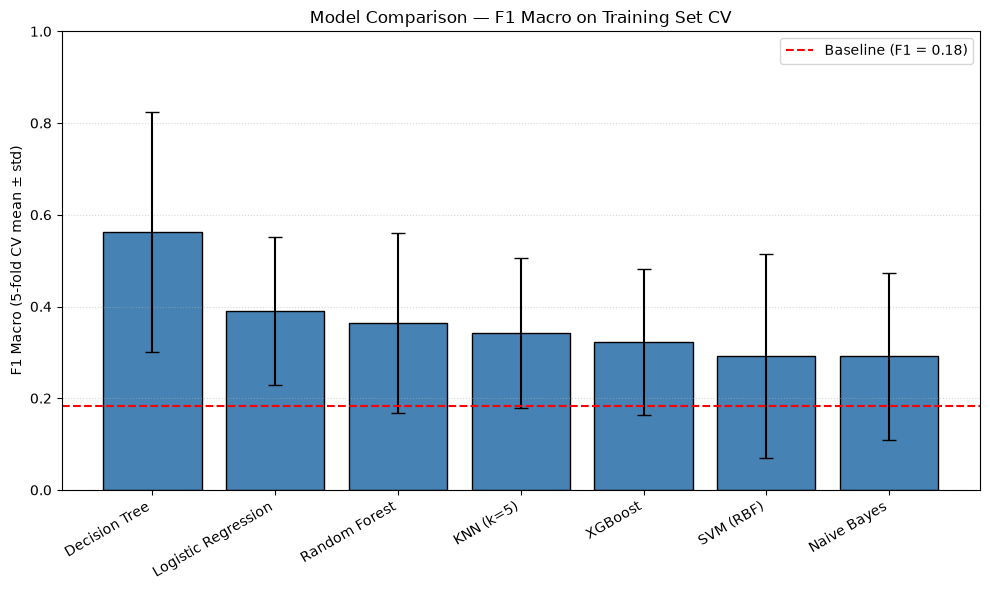

In [6]:
# Step 6: Save comparison table and visualize.

import os
import matplotlib.pyplot as plt

# ---- Save the results table ----
os.makedirs("../reports", exist_ok=True)
results_df.to_csv("../reports/model_comparison.csv", index=False)
print("Saved: ../reports/model_comparison.csv")

# ---- Baseline values (from earlier step) ----
baseline_acc = 0.386
baseline_f1  = 0.184

# ---- Bar chart: F1 macro with error bars ----
fig, ax = plt.subplots(figsize=(10, 6))

positions = range(len(results_df))
bars = ax.bar(
    positions,
    results_df["F1 Mean"],
    yerr=results_df["F1 Std"],
    capsize=5,
    color="steelblue",
    edgecolor="black"
)

# Baseline reference line
ax.axhline(baseline_f1, color="red", linestyle="--", linewidth=1.5,
           label=f"Baseline (F1 = {baseline_f1:.2f})")

# Labeling
ax.set_xticks(positions)
ax.set_xticklabels(results_df["Model"], rotation=30, ha="right")
ax.set_ylabel("F1 Macro (5-fold CV mean ± std)")
ax.set_title("Model Comparison — F1 Macro on Training Set CV")
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

## Step 7 — Select and Save Best Model

Based on 5-fold CV F1 macro, **Decision Tree** is the best-performing
model (F1 = 0.562 ± 0.262). We fit it on the entire training set and
save it for evaluation on the held-out test set in the next notebook.

**Model selection criteria:** F1 macro, because it weighs all three
classes equally. Accuracy is reported but not used for selection — a
model can achieve high accuracy while ignoring minority classes.

**Limitation:** With n=31 and overlapping CV error bars, this selection
is not statistically robust. It represents our best estimate given the
data, not a definitive conclusion.

In [7]:
# Step 7: Fit best model (Decision Tree) on full training set and save.

import joblib
import os

# Pick the top model from our comparison
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model (by CV F1 macro): {best_model_name}")

# Fetch the actual estimator object
best_model = models[best_model_name]

# Decision Tree uses string labels — no encoding needed here
best_model.fit(X_train_scaled, y_train)

# Save the fitted model
os.makedirs("../models", exist_ok=True)
model_path = f"../models/best_model.pkl"
joblib.dump(best_model, model_path)
print(f"Saved: {model_path}")

# Also save metadata so we remember what we trained
metadata = {
    "model_name": best_model_name,
    "cv_f1_macro_mean": float(results_df.iloc[0]["F1 Mean"]),
    "cv_f1_macro_std": float(results_df.iloc[0]["F1 Std"]),
    "cv_accuracy_mean": float(results_df.iloc[0]["Acc Mean"]),
    "trained_on": "X_train_scaled (n=31, p=37)",
    "test_set": "held out (n=8) — untouched during training",
    "random_state": 42,
    "classes": list(y_train.unique()),
}

import json
with open("../models/best_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved: ../models/best_model_metadata.json")
print()
print("Metadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")

Best model (by CV F1 macro): Decision Tree
Saved: ../models/best_model.pkl
Saved: ../models/best_model_metadata.json

Metadata:
  model_name: Decision Tree
  cv_f1_macro_mean: 0.5622222222222223
  cv_f1_macro_std: 0.261769854624484
  cv_accuracy_mean: 0.6047619047619048
  trained_on: X_train_scaled (n=31, p=37)
  test_set: held out (n=8) — untouched during training
  random_state: 42
  classes: ['Low', 'High', 'Moderate']
